# How to Win the VN1 Competition

## StatsForecast

<p align="center">
  <img src="../img/statsforecast.png" alt="StatsForecast" width="400">
</p>

### _Coming sooon!_ Print version of FPPPY

<p align="center">
  <img src="../img/fpppy.png" alt="FPPPY" width="300">
</p>


In [1]:
import pandas as pd 
import numpy as np
from statsforecast import StatsForecast
from statsforecast.models import (
    HistoricAverage,
    SeasonalNaive,
    HoltWinters,
    ADIDA,
    IMAPA,
    CrostonOptimized,
    AutoARIMA,
    AutoETS,
    AutoTheta,
    AutoCES,
    AutoMFLES,
    Naive
)

In [2]:
# Load prepared data 
df = pd.read_parquet('../data_prepared/df.parquet')
df.head()

,unique_id,ds,y
0,0-1-10705,2020-07-06,7.0
1,0-1-10705,2020-07-13,7.0
2,0-1-10705,2020-07-20,7.0
3,0-1-10705,2020-07-27,7.0
4,0-1-10705,2020-08-03,7.0


In [3]:
# Instantiate StatsForecast
models = [
    HistoricAverage(),
    SeasonalNaive(season_length = 52),
    HoltWinters(season_length = 52), 
    ADIDA(), 
    IMAPA(),
    CrostonOptimized(), 
    AutoARIMA(season_length = 52), 
    AutoETS(season_length = 52),
    AutoTheta(season_length = 52), 
    AutoCES(season_length = 52),
    AutoMFLES(season_length = 52, test_size = 13) # use test size equal to the forecast horizon
]

sf = StatsForecast(
    models = models, 
    freq = 'W-MON',
    fallback_model = Naive(),
    n_jobs = -1 
)

In [ ]:
# fc_stats = sf.forecast(
#     df = df, 
#     h = 13
# )

In [4]:
fc_stats = pd.read_parquet('../output/statsforecast_fc.parquet')
fc_stats['ds'] = pd.to_datetime(fc_stats['ds'])
fc_stats.head()

,unique_id,ds,Naive,HistoricAverage,SeasonalNaive,HoltWinters,ADIDA,IMAPA,CrostonOptimized,RWD,AutoARIMA,AutoETS,AutoTheta,AutoMFLES,CES
0,0-1-10705,2024-01-08,5.0,5.092896,4.0,2.461685,2.400343,2.400343,2.397084,4.989011,2.400343,2.400061,2.310126,1.677481,2.913995
1,0-1-10705,2024-01-15,5.0,5.092896,2.0,1.742490,2.400343,2.400343,2.397084,4.978022,2.400343,2.400061,2.295064,1.666484,2.229754
2,0-1-10705,2024-01-22,5.0,5.092896,0.0,1.030031,2.400343,2.400343,2.397084,4.967033,2.400343,2.400061,2.280003,1.655487,1.589912
3,0-1-10705,2024-01-29,5.0,5.092896,5.0,2.667748,2.400343,2.400343,2.397084,4.956044,2.400343,2.400061,2.264941,1.644489,3.298208
4,0-1-10705,2024-02-05,5.0,5.092896,2.0,1.605380,2.400343,2.400343,2.397084,4.945055,2.400343,2.400061,2.249879,1.633492,2.301137


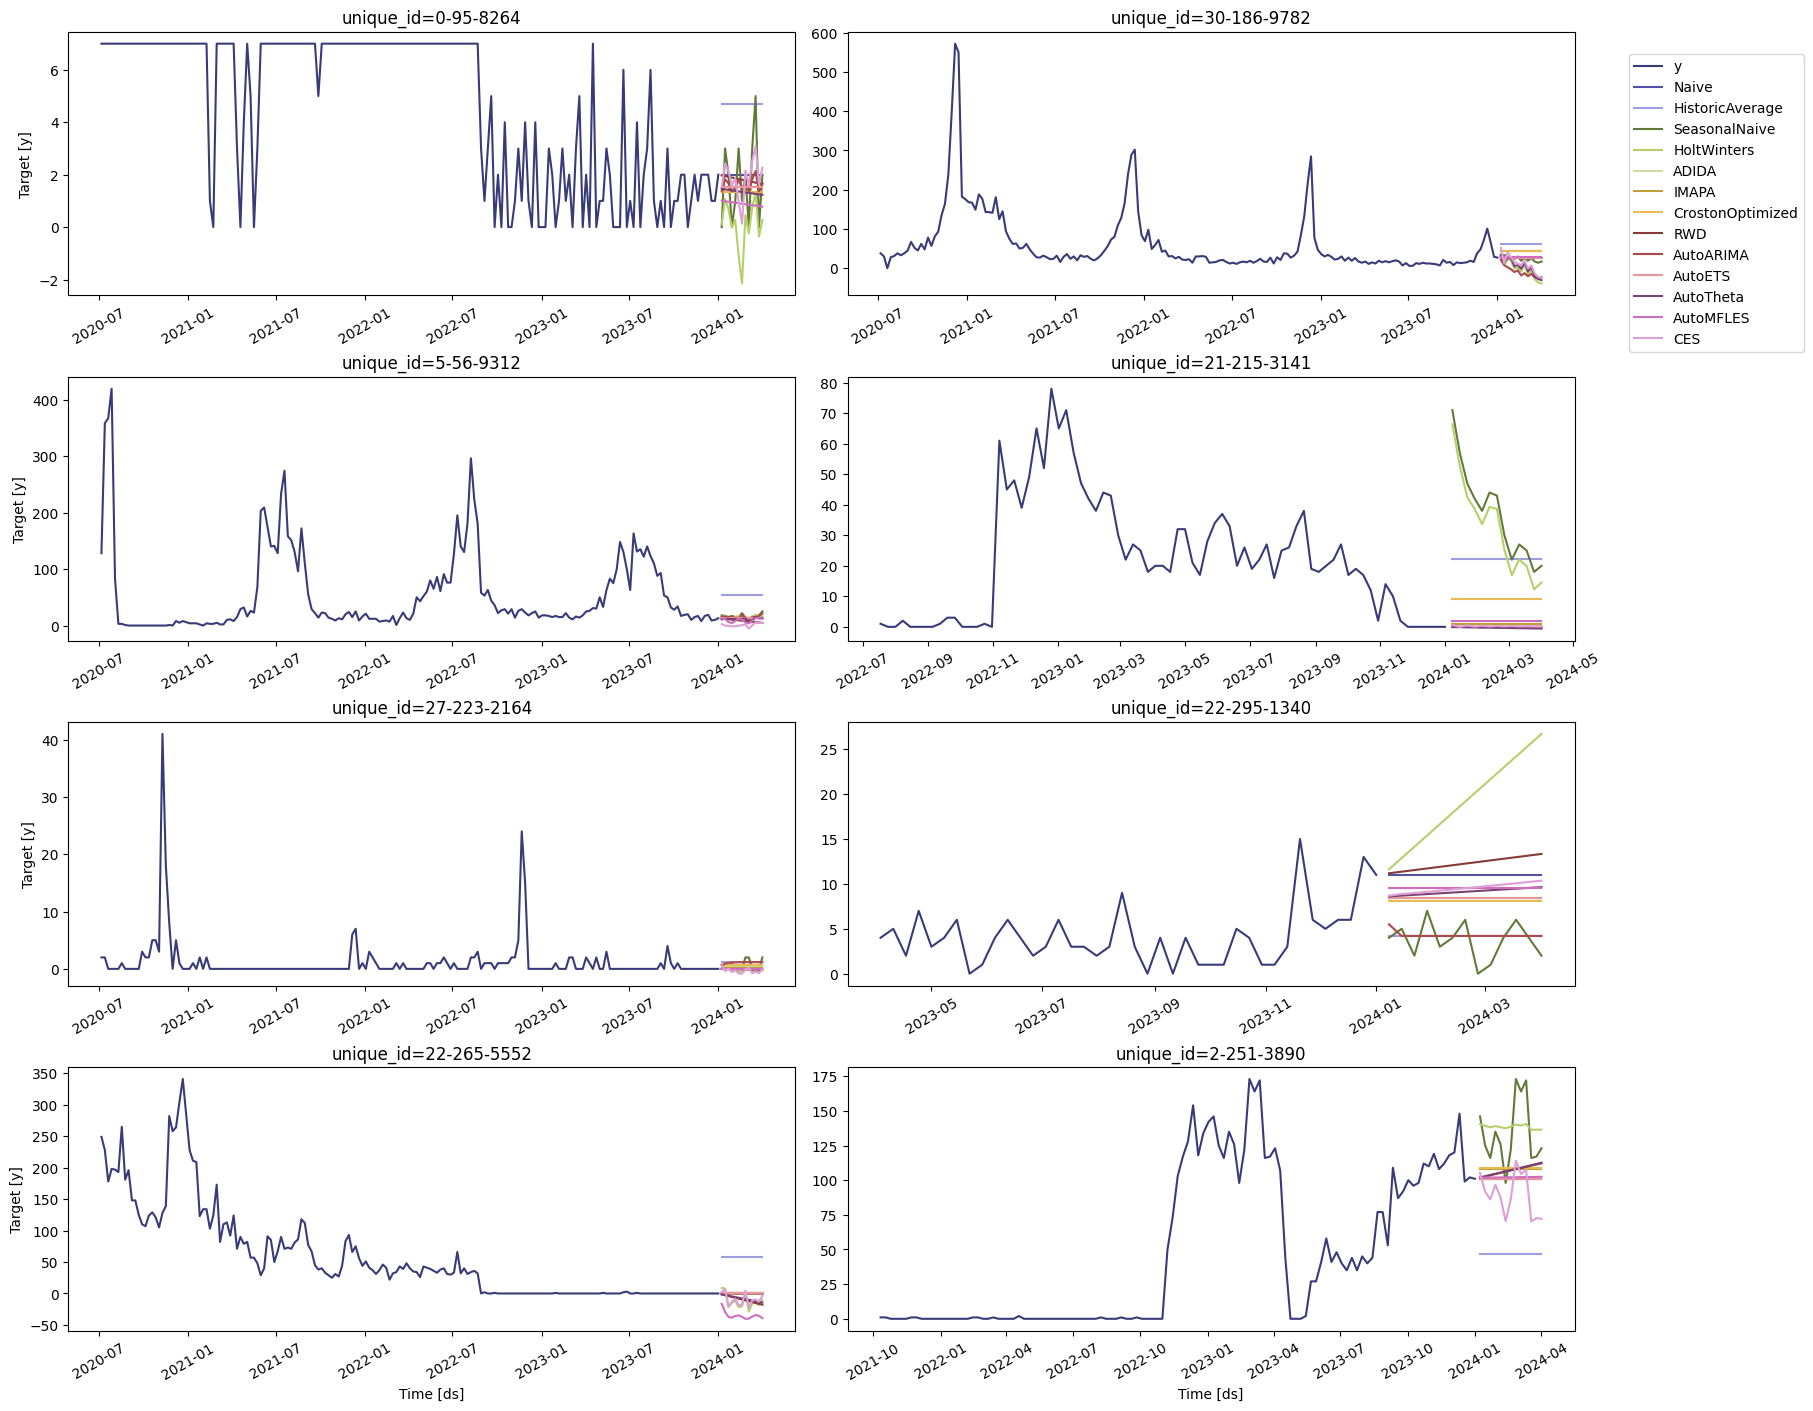

In [5]:
sf.plot(df, fc_stats)

In [6]:
from utils import vn1_competition_evaluation

stats_scores = vn1_competition_evaluation(fc_stats)

In [7]:
winners_scores = pd.read_parquet('../scores/winners_scores.parquet')

results = pd.concat([winners_scores, stats_scores])
results.sort_values(by='score').reset_index(drop=True)

,model,score
0,1st place,0.46375
1,2nd place,0.46568
2,3rd place,0.47578
3,4th place,0.47743
4,5th place,0.48081
5,Naive,0.50697
6,RWD,0.57804
7,AutoTheta,0.58401
8,AutoMFLES,0.60216
9,AutoARIMA,0.62798


## Hierarchical Ensemble 

The data has a natural hierarchy: **Client → Warehouse → Product**. 

**Key Insight**: Forecasts at different hierarchical levels contain complementary information:

- Aggregate (client) level: More stable, less noisy, captures overall demand trends
- Bottom (product) level: Captures product-specific patterns but more volatile

Hierarchical reconciliation combines both levels to produce coherent forecasts

In [8]:
df_client = df.copy()
df_client[['Client', 'Warehouse', 'Product']] = df_client['unique_id'].str.split('-', expand=True)
df_client = df_client.groupby(['Client', 'ds'])['y'].sum().reset_index()
print('There are ', df_client['Client'].nunique(), 'clients in the dataset.')

There are  46 clients in the dataset.


In [ ]:
sf_client = StatsForecast(
    models=[
        AutoARIMA(season_length = 52),
        AutoETS(season_length = 52),
        AutoTheta(season_length = 52),
        AutoCES(season_length = 52)
    ], 
    freq='W-MON', 
    n_jobs=-1, 
    fallback_model=Naive()
)

# fc_client = sf_client.forecast(
#     df=df_client, 
#     h=13, 
#     id_col="Client"
# )

In [10]:
# Client level forecasts
fc_client = pd.read_parquet('../output/stats_fc_client.parquet')
fc_client.head()

,Client,ds,AutoARIMA,AutoETS,AutoTheta,CES
0,0,2024-01-08,36543.562008,45862.989557,45086.734375,33947.504883
1,0,2024-01-15,37194.986154,45862.989557,45082.578125,39851.596191
2,0,2024-01-22,35495.599957,45862.989557,45078.421875,40575.102783
3,0,2024-01-29,35122.769965,45862.989557,45074.265625,51645.729980
4,0,2024-02-05,35015.920542,45862.989557,45070.109375,52033.402344


In [11]:
fc_client['Ensemble'] = fc_client[['AutoARIMA', 'AutoETS', 'CES', 'AutoTheta']].median(axis=1)

### Example of hierarchical reconciliation based on forecast proportions

<p align="center">
  <img src="../img/hierar.png" alt="Hierarchical Ensemble" width="400">
</p>

In [15]:
fc = fc_stats[['unique_id', 'ds', 'CES']+[col for col in fc_stats.columns if 'Auto' in col]].copy()
fc['Ensemble'] = fc[['AutoARIMA', 'AutoETS', 'CES', 'AutoTheta']].median(axis=1)
fc[['Client', 'Warehouse', 'Product']] = fc['unique_id'].str.split('-', expand=True)

In [16]:
total = fc.groupby(['Client', 'ds'])['Ensemble'].sum().reset_index()
total.rename(columns={'Ensemble': 'total_forecasted'}, inplace=True)
total['zero_base_fc'] = np.where(
    total['total_forecasted'] == 0, 
    True, 
    False
)

fc = fc.merge(total, on=['Client', 'ds'], how='left')

fc['fc_proportions'] = fc['Ensemble']/fc['total_forecasted']
fc['fc_proportions'] = fc['fc_proportions'].fillna(0)

fc_client.rename(columns={'Ensemble': 'Ensemble_client', 'unique_id': 'Client'}, inplace=True)

fc = fc.merge(fc_client[['Client', 'ds', 'Ensemble_client']], on=['Client', 'ds'], how='left')

In [17]:
products_per_client = fc.groupby(['Client', 'ds'])['Product'].nunique().reset_index(name='products_per_client')

fc = fc.merge(products_per_client, on=['Client', 'ds'], how='left')

fc['Ensemble-hierar'] = np.where(
    fc['zero_base_fc'] == False,
    fc['fc_proportions']*fc['Ensemble_client'],
    fc['Ensemble_client']/fc['products_per_client']
)

fc_hierar = fc[['unique_id', 'ds', 'Ensemble-hierar']]

To avoid additional dependencies beyond `statsforecast`, we're doing the reconciliation via `pandas`. However, this approach and much more can be done with the `hierarchicalforecast` library. 

In [18]:
hierar_scores = vn1_competition_evaluation(fc_hierar)


res = pd.concat([winners_scores, hierar_scores])
res.sort_values(by='score').reset_index(drop=True)

,model,score
0,1st place,0.46375
1,2nd place,0.46568
2,3rd place,0.47578
3,4th place,0.47743
4,5th place,0.48081
5,Ensemble-hierar,0.48864
